In [1]:
building = 0
time = 24
price = 'Realistic'

# Setup

In [2]:
import torch
import pandas as pd
import numpy as np
import math
import os

import src.data.dataprep as prep
import src.data.featurisation as features

from src.models.lstm import LSTM
from src.models.lstmopt import LSTMOPT
from src.models.lstmopt import CVXLayer

from src.training.training import  Training as Training
from src.training.training_opt import Training as Training_opt

import src.optimization.pv_battery as pvb

import src.tensors.tensorisation as tensor

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error as mse

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

def assign_value(time, night, day):
    if time < pd.Timestamp("08:00:00").time() or time >= pd.Timestamp("19:00:00").time():
        return night
    else:
        return day

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [3]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h')

In [4]:
# Include net load for cost calculations
nl_data['net_load'] = nl_data['load'] - nl_data['solar_energy']
# Import a price profile and merge it with the consumption data

if price == 'Simple':
    # Simple profile
    nl_data.loc[:,'offtake'] = nl_data.index.to_series().apply(lambda x: assign_value(x.time(),0.2,0.3))
    nl_data.loc[:,'injection'] = nl_data.index.to_series().apply(lambda x: assign_value(x.time(),0.05,0.01))
elif price == 'Realistic':
    # Realistic profile
    nl_price_data = pd.read_csv('../data/NL_DA_Prices.csv', index_col='Date',parse_dates=True, dayfirst=True)
    nl_data = nl_data.merge(nl_price_data[['offtake', 'injection']], left_index=True, right_index=True)
    
# calculate the cost to be a positive net load x offtake minus a negative net load x injection
nl_data['cost'] = nl_data.apply(lambda row: row['net_load'] * row['injection'] if row['net_load'] < 0 else row['net_load'] * row['offtake'], axis=1)

In [5]:
featurisation = features.Featurisation(nl_data)
nl_data = featurisation.cyclic_features(yearly=False)[0]
nl_data.head()

,load,solar_energy,net_load,offtake,injection,cost,hour_sin,hour_cos
2018-07-01 00:00:00,0.905,0.0,0.905,0.18878,0.030,0.170846,0.000000,1.000000
2018-07-01 01:00:00,0.404,0.0,0.404,0.18178,0.024,0.073439,0.258819,0.965926
2018-07-01 02:00:00,0.345,0.0,0.345,0.17278,0.018,0.059609,0.500000,0.866025
2018-07-01 03:00:00,0.370,0.0,0.370,0.16278,0.010,0.060229,0.707107,0.707107
2018-07-01 04:00:00,0.552,0.0,0.552,0.16478,0.012,0.090959,0.866025,0.500000


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters

In [7]:
# Base parameters
#battery_capacity = round(nl_data['solar_energy'].max() * 1.2,1)
#battery_capacity = math.floor(nl_data['load'].resample('D').sum().max())
kwp_pv = 6
battery_capacity = kwp_pv * 2
max_charge = battery_capacity/2.7
max_discharge = max_charge
epochs = 200
layers = 3
neurons = 200
features = 3
train_test_split = 0.6

past_features = ['solar_energy']
future_features = ['hour_sin','hour_cos']
opt_future_features = ['hour_sin','hour_cos','load','offtake','injection']
domain_min = [None, None, None, 0, 0, 0, None]
domain_max = [None, None, None, 1, 1, 1, None]

In [8]:
pvb_system = pvb.PV_battery(nl_data, battery_capacity, max_charge, max_discharge, self_consumption=False)

In [9]:
problem, variables, parameters = pvb_system.create_optimization_problem(24)

In [10]:
# Tensors for training
nl_opt_tensors = tensor.Tensors(nl_data,'solar_energy',past_features,opt_future_features,24,24,forecast_gap=0,train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)
X_train, X_test, y_train, y_test, scalers_opt = nl_opt_tensors.create_tensor()

In [11]:
y_train.shape, y_test.shape

(torch.Size([676, 24]), torch.Size([450, 24]))

# Previous problems

We first need the initial battery states for the hour prior to the current optimization as input for our current optimization. This requires looping over all previous timeslots, as every consecutive optimization needs the initial battery state coming from the previous one.

In [12]:
# We evaluate how many times we need to loop over the optimization
problems = 24 - time

In [13]:
# We keep the train initial batteries in this list
initial_battery_train_cvx = []
initial_battery_train_lstm_cvx = []

# We keep the test initial batteries in this list
initial_battery_test_perfect = []
initial_battery_test_naive = []
initial_battery_test_lstm = []
initial_battery_test_cvx = []
initial_battery_test_lstm_cvx = []

# These values get updated each loop
old_T = 24          # The first timeslot under consideration: 24 hours to optimize 
lags = 24           # The number of lags for this first timeslot: the 24 previous hours
forecast_gap = 0    # The gap after every forecast which is 0 when we need to forecast 24 hours

# loop over each of the problems
for i in range(problems):
       
    print('Setting up optimization for hour ' + str(i))
    
    # Get the optimization problem for the current problem
    problem, variables, parameters = pvb_system.create_optimization_problem(old_T)
    
    # Get what actually happens based on the (dis)charging scheme to obtain the initial battery value for the next hour
    problem_post, variables_post, parameters_post = pvb_system.create_post_forecast_optimization_problem(old_T)

    
    # Tensors for training a base forecaster
    tensors = tensor.Tensors(pvb_system.house,'solar_energy',past_features,future_features,lags,old_T, forecast_gap=forecast_gap,train_test_split=train_test_split)
    X_train, X_test, y_train, y_test, scalers = tensors.create_tensor()
    
    
    # Tensors for training an E2E network
    tensors_cvx = tensor.Tensors(pvb_system.house,'solar_energy',past_features,opt_future_features,lags,old_T, forecast_gap=forecast_gap, train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)
    tensors_lstm_cvx = tensor.Tensors(pvb_system.house,'solar_energy',past_features,opt_future_features,lags,old_T, forecast_gap=forecast_gap, train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)


    # We don't need the Y values as they are identical to the ones from the base forecaster
    _, X_test_perfect, _, _, scalers_perfect = tensors_cvx.create_tensor()
    _, X_test_naive, _, _, scalers_naive = tensors_cvx.create_tensor()
    _, X_test_lstm, _, _, scalers_lstm = tensors_cvx.create_tensor()
    X_train_cvx, X_test_cvx, _, _, scalers_cvx = tensors_cvx.create_tensor()
    X_train_lstm_cvx, X_test_lstm_cvx, _, _, scalers_lstm_cvx = tensors_lstm_cvx.create_tensor()

    # We have to assign initial battery values to the current optimization at hand, first we create an empty tensor
    initial_bat_tensor_test_perfect = torch.zeros([X_test_perfect.shape[0],lags,1])

    initial_bat_tensor_test_naive = torch.zeros([X_test_naive.shape[0],lags,1])

    initial_bat_tensor_test_lstm = torch.zeros([X_test_lstm.shape[0],lags,1])

    initial_bat_tensor_train_cvx = torch.zeros([X_train_cvx.shape[0],lags,1])
    initial_bat_tensor_test_cvx = torch.zeros([X_test_cvx.shape[0],lags,1])

    initial_bat_tensor_train_lstm_cvx = torch.zeros([X_train_lstm_cvx.shape[0],lags,1])
    initial_bat_tensor_test_lstm_cvx = torch.zeros([X_test_lstm_cvx.shape[0],lags,1])

    # If this is the first optimization done at midnight, the initial battery is set at 50% of the capacity, as we also make sure that the end
    # state of the battery from the previous day is 50%
    if i == 0:       
        initial_bat_tensor_test_perfect[:,-1,:] = battery_capacity * 0.5

        initial_bat_tensor_test_naive[:,-1,:] = battery_capacity * 0.5

        initial_bat_tensor_test_lstm[:,-1,:] = battery_capacity * 0.5

        initial_bat_tensor_train_cvx[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_cvx[:,-1,:] = battery_capacity * 0.5

        initial_bat_tensor_train_lstm_cvx[:,-1,:] = battery_capacity * 0.5
        initial_bat_tensor_test_lstm_cvx[:,-1,:] = battery_capacity * 0.5


    # If it is not the first optimization, we obtain the initial battery values from the list of battery values we have been maintaining 
    else:
        initial_bat_tensor_test_perfect[:,-1,:] = torch.tensor(initial_battery_test_perfect[i-1]).unsqueeze(-1)

        initial_bat_tensor_test_naive[:,-1,:] = torch.tensor(initial_battery_test_naive[i-1]).unsqueeze(-1)

        initial_bat_tensor_test_lstm[:,-1,:] = torch.tensor(initial_battery_test_lstm[i-1]).unsqueeze(-1)

        initial_bat_tensor_train_cvx[:,-1,:] = torch.tensor(initial_battery_train_cvx[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_cvx[:,-1,:] = torch.tensor(initial_battery_test_cvx[i-1]).unsqueeze(-1) 

        initial_bat_tensor_train_lstm_cvx[:,-1,:] = torch.tensor(initial_bat_tensor_train_lstm_cvx[i-1]).unsqueeze(-1)
        initial_bat_tensor_test_lstm_cvx[:,-1,:] = torch.tensor(initial_bat_tensor_test_lstm_cvx[i-1]).unsqueeze(-1)

    # We add this tensor to our X tensors for the E2E network
    X_test_perfect = torch.concat([X_test_perfect, initial_bat_tensor_test_perfect],dim=-1)

    X_test_naive = torch.concat([X_test_naive, initial_bat_tensor_test_naive],dim=-1)

    X_test_lstm = torch.concat([X_test_lstm, initial_bat_tensor_test_lstm],dim=-1)

    X_train_cvx = torch.concat([X_train_cvx, initial_bat_tensor_train_cvx],dim=-1)
    X_test_cvx = torch.concat([X_test_cvx, initial_bat_tensor_test_cvx],dim=-1)

    X_train_lstm_cvx = torch.concat([X_train_lstm_cvx, initial_bat_tensor_train_lstm_cvx],dim=-1)
    X_test_lstm_cvx = torch.concat([X_test_lstm_cvx, initial_bat_tensor_test_lstm_cvx],dim=-1)

    # Create the models for PV forecasts
    lstm = LSTM(features, neurons, layers, old_T, 0.5).to(device)
    cvx = LSTMOPT(features,neurons,layers,old_T,0.5,problem,parameters,variables,scalers_cvx[0]).to(device)
    lstm_cvx = LSTMOPT(features,neurons,layers,old_T,0.5,problem,parameters,variables,scalers_lstm_cvx[0]).to(device)

    lstm.load_state_dict(torch.load('../models/LSTM/building_' + str(building) + '_' + str(old_T) + 'h.pth'))
    cvx.load_state_dict(torch.load('../models/CVX/building_' + str(building) + '_' + str(old_T) + 'h.pth'))
    lstm_cvx.load_state_dict(torch.load('../models/CVX_LSTM/building_' + str(building) + '_' + str(old_T) + 'h.pth'))

    print('Forecasting PV')
    
    # Forecast the PV
    pv_perfect_test = y_test

    pv_naive_test = X_test[:,:,0]

    pv_lstm_test = lstm(X_test.to(device))

    pv_cvx_train, _ = cvx(X_train_cvx[:,:,0:-4].to(device),
                         X_train_cvx[:,-old_T:,-4].to(device),
                         X_train_cvx[:,-old_T:,-3].to(device),
                         X_train_cvx[:,-old_T:,-2].to(device),
                         X_train_cvx[:,-1,-1].to(device))
    
    pv_cvx_test, _ = cvx(X_test_cvx[:,:,0:-4].to(device),
                         X_test_cvx[:,-old_T:,-4].to(device),
                         X_test_cvx[:,-old_T:,-3].to(device),
                         X_test_cvx[:,-old_T:,-2].to(device),
                         X_test_cvx[:,-1,-1].to(device))

    pv_lstm_cvx_train, _ = lstm_cvx(X_train_lstm_cvx[:,:,0:-4].to(device),
                                    X_train_lstm_cvx[:,-old_T:,-4].to(device),
                                    X_train_lstm_cvx[:,-old_T:,-3].to(device),
                                    X_train_lstm_cvx[:,-old_T:,-2].to(device),
                                    X_train_lstm_cvx[:,-1,-1].to(device))

    pv_lstm_cvx_test, _ = lstm_cvx(X_test_lstm_cvx[:,:,0:-4].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-4].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-3].to(device),
                                   X_test_lstm_cvx[:,-old_T:,-2].to(device),
                                   X_test_lstm_cvx[:,-1,-1].to(device))


    # Make a list for the initial energy of the current timeslot for each day in the train and test sets
    cvx_train_initial_energy_t = []
    lstm_cvx_train_initial_energy_t = []

    perfect_test_initial_energy_t = []
    naive_test_initial_energy_t = []
    lstm_test_initial_energy_t = []
    cvx_test_initial_energy_t = []
    lstm_cvx_test_initial_energy_t = []


    print('Obtaining initial energy parameters for hour ' + str(i+1))
    
    # Loop over every day, first use the forecast of PV, next plug in the real PV and the charge and discharge schedules to obtain the real battery state
    for j in range(len(X_train)):           
        # CVX forecast
        parameters[0].value = torch_py(rescale(pv_cvx_train[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_train_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_train_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_train_cvx[j,-old_T:,-2])
        parameters[4].value = torch_py(X_train_cvx[j,-1:,-1])[0]
        problem.solve()
    
        # CVX real
        parameters_post[0].value = torch_py(rescale(y_train[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_train_cvx[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_train_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_train_cvx[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_train_cvx[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        cvx_train_initial_energy_t.append(variables_post[-1].value[1])

        # LSTM-CVX forecast
        parameters[0].value = torch_py(rescale(pv_lstm_cvx_train[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_train_lstm_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_train_lstm_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_train_lstm_cvx[j,-old_T:,-2])
        parameters[4].value = torch_py(X_train_lstm_cvx[j,-1:,-1])[0]
        problem.solve()

        # LSTM-CVX real
        parameters_post[0].value = torch_py(rescale(y_train[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_train_lstm_cvx[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_train_lstm_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_train_lstm_cvx[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_train_lstm_cvx[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        lstm_cvx_train_initial_energy_t.append(variables_post[-1].value[1])


    # Do the same for the test set
    for j in range(len(X_test)):   
        # Perfect forecast
        parameters[0].value = torch_py(rescale(pv_perfect_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_perfect[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_perfect[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_perfect[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_perfect[j,-1:,-1])[0]
        problem.solve()
        perfect_test_initial_energy_t.append(variables[-4].value[1])

        # Naive forecast
        parameters[0].value = torch_py(rescale(pv_naive_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_naive[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_naive[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_naive[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_naive[j,-1:,-1])[0]
        problem.solve()

        # Naive real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_naive[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_naive[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_naive[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_test_naive[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        naive_test_initial_energy_t.append(variables_post[-1].value[1])

        # LSTM forecast
        parameters[0].value = torch_py(rescale(pv_lstm_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_lstm[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_lstm[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_lstm[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_lstm[j,-1:,-1])[0]
        problem.solve()

        # LSTM real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_lstm[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_lstm[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_lstm[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_test_lstm[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        lstm_test_initial_energy_t.append(variables_post[-1].value[1])

        # CVX forecast
        parameters[0].value = torch_py(rescale(pv_cvx_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_cvx[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_cvx[j,-1:,-1])[0]
        problem.solve()
    
        # CVX real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_cvx[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_cvx[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_test_cvx[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        cvx_test_initial_energy_t.append(variables_post[-1].value[1])

        # LSTM-CVX forecast
        parameters[0].value = torch_py(rescale(pv_lstm_cvx_test[j], scalers_cvx[0]))
        parameters[1].value = torch_py(X_test_lstm_cvx[j,-old_T:,-4])
        parameters[2].value = torch_py(X_test_lstm_cvx[j,-old_T:,-3])
        parameters[3].value = torch_py(X_test_lstm_cvx[j,-old_T:,-2])
        parameters[4].value = torch_py(X_test_lstm_cvx[j,-1:,-1])[0]
        problem.solve()

        # LSTM-CVX real
        parameters_post[0].value = torch_py(rescale(y_test[j,:], scalers[0]))
        parameters_post[1].value = torch_py(X_test_lstm_cvx[j,-old_T:,-4])
        parameters_post[2].value = torch_py(X_test_lstm_cvx[j,-old_T:,-3])
        parameters_post[3].value = torch_py(X_test_lstm_cvx[j,-old_T:,-2])
        parameters_post[4].value = torch_py(X_test_lstm_cvx[j,-1:,-1])[0]
        parameters_post[5].value = variables[-2].value
        parameters_post[6].value = variables[-1].value
        problem_post.solve()
        lstm_cvx_test_initial_energy_t.append(variables_post[-1].value[1])


    # Add the initial battery values to our list
    initial_battery_test_perfect.append(perfect_test_initial_energy_t)

    initial_battery_test_naive.append(naive_test_initial_energy_t)

    initial_battery_test_lstm.append(lstm_test_initial_energy_t)

    initial_battery_train_cvx.append(cvx_train_initial_energy_t)
    initial_battery_test_cvx.append(cvx_test_initial_energy_t)

    initial_battery_train_lstm_cvx.append(lstm_cvx_train_initial_energy_t)
    initial_battery_test_lstm_cvx.append(lstm_cvx_test_initial_energy_t)

    old_T += -1         # Update the timeslots we have to forecast, 1 less than the previous optimization
    lags += 1           # Update the lags we can use for the forecast, we still use the full previous day, but have 1 more hour of the current day as well
    forecast_gap += 1   # Add to the gap between forecasts (f.e. the gap is 1 if we only have to forecast 23 hours)

# LSTM model

First we make forecasts in a 2-step approach, for which we do not need the optimization.

## Tensors

In [14]:
# Tensors for training
nl_tensors = tensor.Tensors(pvb_system.house,'solar_energy',past_features,future_features,lags,time,forecast_gap=forecast_gap,train_test_split=train_test_split)
X_train_base, X_test_base, y_train_base, y_test_base, scalers = nl_tensors.create_tensor()

## Model

In [15]:
lstm = LSTM(features,neurons,layers,time,0.5).to(device)

In [16]:
file_path = f"../models/LSTM/building_{building}_{time}h.pth"

if os.path.exists(file_path):
    lstm.load_state_dict(torch.load('../models/LSTM/building_' + str(building) + '_' + str(time) + 'h.pth'))
else:
    trainer_base = Training(lstm, X_train_base, y_train_base, X_test_base, y_test_base, epochs, learning_rate=0.0005)
    state_dicts_lstm, best_lstm = trainer_base.fit(verbose=2)
    lstm.load_state_dict(state_dicts_lstm[best_lstm])

# LSTM-CVX model

Next we make a model which integrates the optimization and the forecast. For this we need all parameters to do the optimization.

## Tensors

In [17]:
# Tensors for training
nl_opt_tensors = tensor.Tensors(nl_data,'solar_energy',past_features,opt_future_features,lags,time,forecast_gap=forecast_gap, train_test_split=train_test_split, domain_min=domain_min, domain_max=domain_max)
X_train, X_test, _, _, scalers_opt = nl_opt_tensors.create_tensor()

In [18]:
# Here we use the initial battery states which we obtained earlier from running the previous optimization programs

# Create an empty tensor to add to the X tensors
initial_bat_tensor_perfect_test = torch.zeros([X_test.shape[0],lags,1])

initial_bat_tensor_naive_test = torch.zeros([X_test.shape[0],lags,1])

initial_bat_tensor_lstm_test = torch.zeros([X_test.shape[0],lags,1])

initial_bat_tensor_cvx_train = torch.zeros([X_train.shape[0],lags,1])
initial_bat_tensor_cvx_test = torch.zeros([X_test.shape[0],lags,1])

initial_bat_tensor_lstm_cvx_train = torch.zeros([X_train.shape[0],lags,1])
initial_bat_tensor_lstm_cvx_test = torch.zeros([X_test.shape[0],lags,1])


# If this is the first optimization done at midnight, the initial battery is set at 50% of the capacity, as we also make sure that the end
# state of the battery from the previous day is 50%
if problems == 0:
    initial_bat_tensor_perfect_test[:,-1,:] = battery_capacity * 0.5

    initial_bat_tensor_naive_test[:,-1,:] = battery_capacity * 0.5

    initial_bat_tensor_lstm_test[:,-1,:] = battery_capacity * 0.5

    initial_bat_tensor_cvx_train[:,-1,:] = battery_capacity * 0.5
    initial_bat_tensor_cvx_test[:,-1,:] = battery_capacity * 0.5

    initial_bat_tensor_lstm_cvx_train[:,-1,:] = battery_capacity * 0.5
    initial_bat_tensor_lstm_cvx_test[:,-1,:] = battery_capacity * 0.5


# If it is not the first optimization, we obtain the initial battery values from the list of battery values we have been maintaining 
else:
    initial_bat_tensor_perfect_test[:,-1,:] = torch.tensor(initial_battery_test_perfect[-1]).unsqueeze(-1)

    initial_bat_tensor_naive_test[:,-1,:] = torch.tensor(initial_battery_test_naive[-1]).unsqueeze(-1)

    initial_bat_tensor_lstm_test[:,-1,:] = torch.tensor(initial_battery_test_lstm[-1]).unsqueeze(-1)

    initial_bat_tensor_cvx_train[:,-1,:] = torch.tensor(initial_battery_train_cvx[-1]).unsqueeze(-1)
    initial_bat_tensor_cvx_test[:,-1,:] = torch.tensor(initial_battery_test_cvx[-1]).unsqueeze(-1)

    initial_bat_tensor_lstm_cvx_train[:,-1,:] = torch.tensor(initial_battery_train_lstm_cvx[-1]).unsqueeze(-1)
    initial_bat_tensor_lstm_cvx_test[:,-1,:] = torch.tensor(initial_battery_test_lstm_cvx[-1]).unsqueeze(-1)

X_test_perfect = torch.concat([X_test, initial_bat_tensor_perfect_test],dim=-1)

X_test_naive = torch.concat([X_test, initial_bat_tensor_naive_test],dim=-1)

X_test_lstm = torch.concat([X_test, initial_bat_tensor_lstm_test],dim=-1)

X_train_cvx = torch.concat([X_train, initial_bat_tensor_cvx_train],dim=-1)
X_test_cvx = torch.concat([X_test, initial_bat_tensor_cvx_test],dim=-1)

X_train_lstm_cvx = torch.concat([X_train, initial_bat_tensor_lstm_cvx_train],dim=-1)
X_test_lstm_cvx = torch.concat([X_test, initial_bat_tensor_lstm_cvx_test],dim=-1)

In [19]:
# Create the current optimization problem
problem, variables, parameters = pvb_system.create_optimization_problem(time)

In [20]:
# Now we need to have optimal solutions given correct PV values in order to obtain the "regret" for training the E2E forecaster

# Create a CVXLayer (or just use a cvxpy solver, the result should be the same)
cvx_real = CVXLayer(problem, parameters, variables)

# get the optimal parameters for the train set
cvx_vars_train = cvx_real(rescale(y_train_base,scalers[-1]),
                          X_train_cvx[:,-time:,-4],
                          X_train_cvx[:,-time:,-3],
                          X_train_cvx[:,-time:,-2],
                          X_train_cvx[:,-1,-1])

lstm_cvx_vars_train = cvx_real(rescale(y_train_base,scalers[-1]),
                          X_train_lstm_cvx[:,-time:,-4],
                          X_train_lstm_cvx[:,-time:,-3],
                          X_train_lstm_cvx[:,-time:,-2],
                          X_train_lstm_cvx[:,-1,-1])

# get the optimal parameters for the test set
cvx_vars_test = cvx_real(rescale(y_test_base,scalers[-1]),
                         X_test_cvx[:,-time:,-4],
                         X_test_cvx[:,-time:,-3],
                         X_test_cvx[:,-time:,-2],
                         X_test_cvx[:,-1,-1])

lstm_cvx_vars_test = cvx_real(rescale(y_test_base,scalers[-1]),
                          X_test_lstm_cvx[:,-time:,-4],
                          X_test_lstm_cvx[:,-time:,-3],
                          X_test_lstm_cvx[:,-time:,-2],
                          X_test_lstm_cvx[:,-1,-1])

In [21]:
# Obtain the optimal outcomes: load x off-take - excess energy x injection
solution_cvx_train = torch.sub(torch.mul(cvx_vars_train[0], X_train_cvx[:,-time:,-3]),
                   torch.mul(cvx_vars_train[1], X_train_cvx[:,-time:,-2])).unsqueeze(-1)

solution_cvx_test = torch.sub(torch.mul(cvx_vars_test[0], X_test_cvx[:,-time:,-3]),
                 torch.mul(cvx_vars_test[1], X_test_cvx[:,-time:,-2])).unsqueeze(-1)

solution_lstm_cvx_train = torch.sub(torch.mul(lstm_cvx_vars_train[0], X_train_lstm_cvx[:,-time:,-3]),
                   torch.mul(lstm_cvx_vars_train[1], X_train_lstm_cvx[:,-time:,-2])).unsqueeze(-1)

solution_lstm_cvx_test = torch.sub(torch.mul(lstm_cvx_vars_test[0], X_test_lstm_cvx[:,-time:,-3]),
                 torch.mul(lstm_cvx_vars_test[1], X_test_lstm_cvx[:,-time:,-2])).unsqueeze(-1)

In [22]:
# Add the optimal costs to the Y tensor which now holds the correct PV values and the optimal costs, using the correct PV values
y_train_cvx = torch.cat([y_train_base.unsqueeze(-1), solution_cvx_train], dim=-1)
y_test_cvx = torch.cat([y_test_base.unsqueeze(-1), solution_cvx_test], dim=-1)

y_train_lstm_cvx = torch.cat([y_train_base.unsqueeze(-1), solution_cvx_train], dim=-1)
y_test_lstm_cvx = torch.cat([y_test_base.unsqueeze(-1), solution_cvx_test], dim=-1)

In [23]:
# Create the post-forecast optimization problem which we need to calculate the regret
problem_post, variables_post, parameters_post = pvb_system.create_post_forecast_optimization_problem(time)
cvx_post = CVXLayer(problem_post, parameters_post, variables_post)

## Models

In [24]:
# CVX model
cvx_opt = LSTMOPT(features,neurons,layers,time,0.5,problem,parameters,variables,scalers_opt[0]).to(device)
# LSTM to CVX model
lstm_cvx_opt = LSTMOPT(features,neurons,layers,time,0.5,problem,parameters,variables,scalers_opt[0]).to(device)

In [25]:
# CVX model
trainer_1 = Training_opt(cvx_opt,
                       cvx_post, 
                       X_train_cvx,
                       y_train_cvx,
                       X_test_cvx,
                       y_test_cvx,
                       scalers_opt[0], 
                       epochs, 
                       time, 
                       battery_capacity, 
                       min_beta=1, max_beta=1, learning_rate=0.0001, lr_decay=None)

# LSTM to CVX model
trainer_2 = Training_opt(lstm_cvx_opt,
                       cvx_post,
                       X_train_lstm_cvx,
                       y_train_lstm_cvx,
                       X_test_lstm_cvx,
                       y_test_lstm_cvx,
                       scalers_opt[0],
                       epochs-100,
                       time,
                       battery_capacity,
                       min_beta=1, max_beta=1, learning_rate=0.0001, lr_decay=None)

Step 0:
Average train loss: 0.0189 | Average test loss: 0.0139
   Regret: 0.0189 | 0.0139
   MSE: 0.0786 | 0.0786

MSE: 0.00 | Regret: 1.00
Step 5:
Average train loss: 0.0094 | Average test loss: 0.0083
   Regret: 0.0094 | 0.0083
   MSE: 0.0479 | 0.0492
Step 10:
Average train loss: 0.0082 | Average test loss: 0.0074
   Regret: 0.0082 | 0.0074
   MSE: 0.0429 | 0.0435
Step 15:
Average train loss: 0.0082 | Average test loss: 0.0063
   Regret: 0.0082 | 0.0063
   MSE: 0.0325 | 0.0347
Step 20:
Average train loss: 0.0063 | Average test loss: 0.0057
   Regret: 0.0063 | 0.0057
   MSE: 0.0250 | 0.0278

MSE: 0.00 | Regret: 1.00
Step 25:
Average train loss: 0.0061 | Average test loss: 0.0055
   Regret: 0.0061 | 0.0055
   MSE: 0.0278 | 0.0278
Step 30:
Average train loss: 0.0055 | Average test loss: 0.0051
   Regret: 0.0055 | 0.0051
   MSE: 0.0257 | 0.0287
Step 35:
Average train loss: 0.0068 | Average test loss: 0.0055
   Regret: 0.0068 | 0.0055
   MSE: 0.0278 | 0.0255
Step 40:
Average train loss: 0

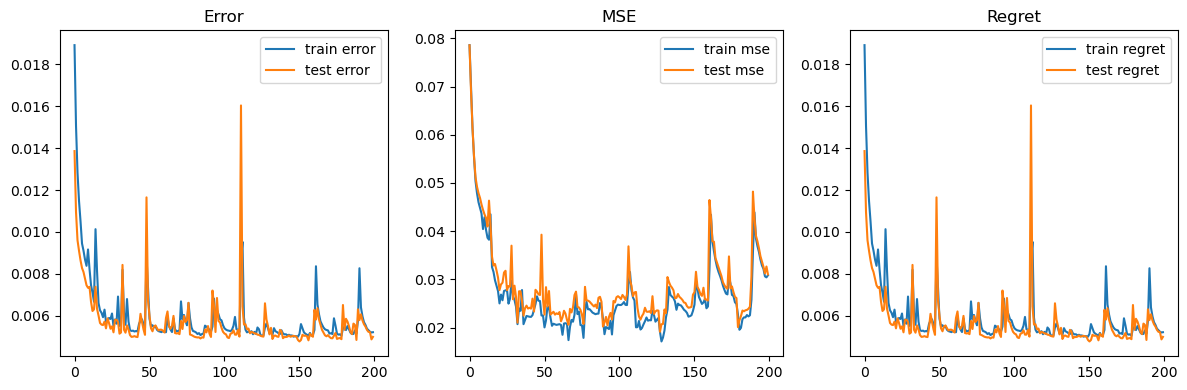

<All keys matched successfully>

In [26]:
state_dicts_cvx, best_cvx = trainer_1.fit(verbose=2)
cvx_opt.load_state_dict(state_dicts_cvx[best_cvx])

Step 0:
Average train loss: 0.0054 | Average test loss: 0.0055
   Regret: 0.0054 | 0.0055
   MSE: 0.0108 | 0.0134

MSE: 0.00 | Regret: 1.00
Step 5:
Average train loss: 0.0044 | Average test loss: 0.0048
   Regret: 0.0044 | 0.0048
   MSE: 0.0155 | 0.0159
Step 10:
Average train loss: 0.0044 | Average test loss: 0.0045
   Regret: 0.0044 | 0.0045
   MSE: 0.0170 | 0.0170

MSE: 0.00 | Regret: 1.00
Step 15:
Average train loss: 0.0045 | Average test loss: 0.0045
   Regret: 0.0045 | 0.0045
   MSE: 0.0174 | 0.0179
Step 20:
Average train loss: 0.0045 | Average test loss: 0.0046
   Regret: 0.0045 | 0.0046
   MSE: 0.0176 | 0.0179

MSE: 0.00 | Regret: 1.00
Step 25:
Average train loss: 0.0043 | Average test loss: 0.0045
   Regret: 0.0043 | 0.0045
   MSE: 0.0179 | 0.0183
Step 30:
Average train loss: 0.0055 | Average test loss: 0.0054
   Regret: 0.0055 | 0.0054
   MSE: 0.0187 | 0.0198

MSE: 0.00 | Regret: 1.00
Step 35:
Average train loss: 0.0044 | Average test loss: 0.0044
   Regret: 0.0044 | 0.0044
  

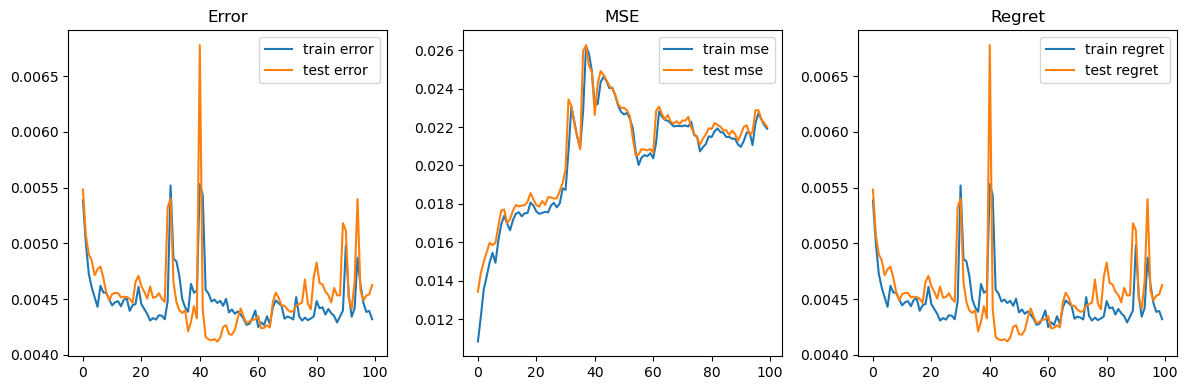

<All keys matched successfully>

In [27]:
lstm_cvx_opt.load_state_dict(lstm.state_dict())
state_dicts_lstm_cvx, best_lstm_cvx = trainer_2.fit(verbose=2)
lstm_cvx_opt.load_state_dict(state_dicts_lstm_cvx[best_lstm_cvx])

In [28]:
if not os.path.exists(file_path):
    torch.save(lstm.state_dict(), '../models/LSTM/building_' + str(building) + '_' + str(time) + 'h_' + str(battery_capacity) + 'kwh.pth')
    
torch.save(cvx_opt.state_dict(), '../models/CVX/building_' + str(building) + '_' + str(time) + 'h_' + str(battery_capacity) + 'kwh.pth')
torch.save(lstm_cvx_opt.state_dict(), '../models/LSTM_CVX/building_' + str(building) + '_' + str(time) + 'h_' + str(battery_capacity) + 'kwh.pth')

In [29]:
pv_lstm = lstm(X_test_base.to(device))

pv_cvx, opt_vars_cvx = cvx_opt(X_test_cvx[:,:,0:-4].to(device),
                              X_test_cvx[:,-time:,-4].to(device),
                              X_test_cvx[:,-time:,-3].to(device),
                              X_test_cvx[:,-time:,-2].to(device),
                              X_test_cvx[:,-1,-1].to(device))

pv_lstm_cvx, opt_vars_lstm_cvx = lstm_cvx_opt(X_test_lstm_cvx[:,:,0:-4].to(device),
                              X_test_lstm_cvx[:,-time:,-4].to(device),
                              X_test_lstm_cvx[:,-time:,-3].to(device),
                              X_test_lstm_cvx[:,-time:,-2].to(device),
                              X_test_lstm_cvx[:,-1,-1].to(device))

pv_naive = X_test_base[:,:time,0]

pv_real = y_test_base

print(f"LSTM RMSE: {mse(torch_py(pv_lstm),torch_py(y_test_base)):.2}\n"
      f"CVX RMSE: {mse(torch_py(pv_cvx),torch_py(y_test_base)):.2}\n"
      f"LSTM-CVX RMSE: {mse(torch_py(pv_lstm_cvx),torch_py(y_test_base)):.2}\n"
      f"Naive RMSE: {mse(torch_py(pv_naive),torch_py(y_test_base)):.2}")

LSTM RMSE: 0.013
CVX RMSE: 0.027
LSTM-CVX RMSE: 0.025
Naive RMSE: 0.02


In [30]:
lstm_solutions = []
cvx_solutions = []
lstm_cvx_solutions = []
naive_solutions = []
perfect_solutions = []

for i in range(len(X_test)):
    parameters[0].value = torch_py(rescale(pv_lstm[i,:], scalers_opt[0]))
    parameters[1].value = torch_py(X_test_lstm[i,-time:,-4])
    parameters[2].value = torch_py(X_test_lstm[i,-time:,-3])
    parameters[3].value = torch_py(X_test_lstm[i,-time:,-2])
    parameters[4].value = torch_py(X_test_lstm[i,-1:,-1])[0]
    problem.solve()

    parameters_post[0].value = torch_py(rescale(y_test_base[i,:], scalers[0]))
    parameters_post[1].value = torch_py(X_test_lstm[i,-time:,-4])
    parameters_post[2].value = torch_py(X_test_lstm[i,-time:,-3])
    parameters_post[3].value = torch_py(X_test_lstm[i,-time:,-2])
    parameters_post[4].value = torch_py(X_test_lstm[i,-1:,-1])[0]
    parameters_post[5].value = variables[-2].value
    parameters_post[6].value = variables[-1].value
    solution = problem_post.solve()
    lstm_solutions.append(solution)

for i in range(len(X_test)):
    parameters[0].value = torch_py(rescale(pv_cvx[i,:], scalers_opt[0]))
    parameters[1].value = torch_py(X_test_cvx[i,-time:,-4])
    parameters[2].value = torch_py(X_test_cvx[i,-time:,-3])
    parameters[3].value = torch_py(X_test_cvx[i,-time:,-2])
    parameters[4].value = torch_py(X_test_cvx[i,-1:,-1])[0]
    problem.solve()

    parameters_post[0].value = torch_py(rescale(y_test_base[i,:], scalers[0]))
    parameters_post[1].value = torch_py(X_test_cvx[i,-time:,-4])
    parameters_post[2].value = torch_py(X_test_cvx[i,-time:,-3])
    parameters_post[3].value = torch_py(X_test_cvx[i,-time:,-2])
    parameters_post[4].value = torch_py(X_test_cvx[i,-1:,-1])[0]
    parameters_post[5].value = variables[-2].value
    parameters_post[6].value = variables[-1].value
    solution = problem_post.solve()
    cvx_solutions.append(solution)

for i in range(len(X_test)):
    parameters[0].value = torch_py(rescale(pv_lstm_cvx[i,:], scalers_opt[0]))
    parameters[1].value = torch_py(X_test_lstm_cvx[i,-time:,-4])
    parameters[2].value = torch_py(X_test_lstm_cvx[i,-time:,-3])
    parameters[3].value = torch_py(X_test_lstm_cvx[i,-time:,-2])
    parameters[4].value = torch_py(X_test_lstm_cvx[i,-1:,-1])[0]
    problem.solve()

    parameters_post[0].value = torch_py(rescale(y_test_base[i,:], scalers[0]))
    parameters_post[1].value = torch_py(X_test_lstm_cvx[i,-time:,-4])
    parameters_post[2].value = torch_py(X_test_lstm_cvx[i,-time:,-3])
    parameters_post[3].value = torch_py(X_test_lstm_cvx[i,-time:,-2])
    parameters_post[4].value = torch_py(X_test_lstm_cvx[i,-1:,-1])[0]
    parameters_post[5].value = variables[-2].value
    parameters_post[6].value = variables[-1].value
    solution = problem_post.solve()
    lstm_cvx_solutions.append(solution)

for i in range(len(X_test)):
    parameters[0].value = torch_py(rescale(X_test_naive[i,:time,0], scalers_opt[0]))
    parameters[1].value = torch_py(X_test_naive[i,-time:,-4])
    parameters[2].value = torch_py(X_test_naive[i,-time:,-3])
    parameters[3].value = torch_py(X_test_naive[i,-time:,-2])
    parameters[4].value = torch_py(X_test_naive[i,-1:,-1])[0]
    problem.solve()

    parameters_post[0].value = torch_py(rescale(y_test_base[i,:], scalers[0]))
    parameters_post[1].value = torch_py(X_test_naive[i,-time:,-4])
    parameters_post[2].value = torch_py(X_test_naive[i,-time:,-3])
    parameters_post[3].value = torch_py(X_test_naive[i,-time:,-2])
    parameters_post[4].value = torch_py(X_test_naive[i,-1:,-1])[0]
    parameters_post[5].value = variables[-2].value
    parameters_post[6].value = variables[-1].value
    solution = problem_post.solve()
    naive_solutions.append(solution)

for i in range(len(X_test)):
    parameters[0].value = torch_py(rescale(y_test_base[i,:], scalers_opt[0]))
    parameters[1].value = torch_py(X_test_perfect[i,-time:,-4])
    parameters[2].value = torch_py(X_test_perfect[i,-time:,-3])
    parameters[3].value = torch_py(X_test_perfect[i,-time:,-2])
    parameters[4].value = torch_py(X_test_perfect[i,-1:,-1])[0]
    solution = problem.solve()
    perfect_solutions.append(solution)

print(f"LSTM solution: {sum(lstm_solutions)}\n"
      f"CVX solution: {sum(cvx_solutions)}\n"
      f"LSTM-CVX solution: {sum(lstm_cvx_solutions)}\n"
      f"Naive solution: {sum(naive_solutions)}\n"
      f"Perfect solution: {sum(perfect_solutions)}")

C:\Users\jdepoort\Anaconda3\lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


LSTM solution: 478.26753167227275
CVX solution: 501.36591262894626
LSTM-CVX solution: 473.36005964816064
Naive solution: 494.48192947994215
Perfect solution: 354.3256784391211
